In [53]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from datetime import datetime
#registro de converters para uso do matplotlib
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [ ]:
# Carregamento da base de dados
base = pd.read_csv('../AirPassengers.csv')
base.shape

(144, 2)

In [70]:
base.head(20)

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
5,1949-06,135
6,1949-07,148
7,1949-08,148
8,1949-09,136
9,1949-10,119


In [71]:
# Visualização do tipo de dados dos atributos
print(base.dtypes)

Month            str
#Passengers    int64
dtype: object


In [72]:
# Conversão dos atributos que estão no formato string para formato de data: ANO-MÊS
dateparse = lambda dates: datetime.strptime(dates, '%Y-%m')
base['Month'] = base['Month'].apply(dateparse)

base['Month']

0     1949-01-01
1     1949-02-01
2     1949-03-01
3     1949-04-01
4     1949-05-01
         ...    
139   1960-08-01
140   1960-09-01
141   1960-10-01
142   1960-11-01
143   1960-12-01
Name: Month, Length: 144, dtype: datetime64[us]

In [58]:
base.head(10)

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


In [59]:
# Visualização do índice do dataframe (#Passengers) 
base.index

RangeIndex(start=0, stop=144, step=1)

# Filtra valores por data SEM INDEX

In [60]:
# Visualização por ano e mês
base.loc[base['Month'] == '1949-02', '#Passengers']

1    118
Name: #Passengers, dtype: int64

In [61]:
# Visualização de data específica
base.loc[base['Month'] == datetime(1949,2,1), '#Passengers']

1    118
Name: #Passengers, dtype: int64

In [75]:
# Visualização de data específica
base.loc[base.Month == datetime(1949,2,1), '#Passengers']

1    118
Name: #Passengers, dtype: int64

In [62]:
# Visualização de intervalos
base.loc[base['Month'].between('1950-01-01', '1950-07-31'), '#Passengers']

12    115
13    126
14    141
15    135
16    125
17    149
18    170
Name: #Passengers, dtype: int64

In [76]:
# Visualização de intervalos
base.loc[base.Month.between('1950-01-01', '1950-07-31'), '#Passengers']

12    115
13    126
14    141
15    135
16    125
17    149
18    170
Name: #Passengers, dtype: int64

# transforma data no index e filtra PELO INDEX

In [77]:
base = base.set_index('Month')

In [78]:
base.loc['1949-02-01']

#Passengers    118
Name: 1949-02-01 00:00:00, dtype: int64

In [68]:
base.loc[datetime(1949,2,1)]

#Passengers    118
Name: 1949-02-01 00:00:00, dtype: int64

In [67]:
base.loc['1950-01-01':'1950-07-31']

,#Passengers
Month,
1950-01-01,115
1950-02-01,126
1950-03-01,141
1950-04-01,135
1950-05-01,125
1950-06-01,149
1950-07-01,170


In [80]:
# Visualização de intervalos sem preencher a data de início
base.loc[:'1950-07-31']

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


# SERIE TEMPORAL

In [79]:
#criação da série temporal (ts)
ts = base['#Passengers']
ts

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: #Passengers, Length: 144, dtype: int64

In [22]:
# Visualização de registro específico
ts[1]

np.int64(118)

In [81]:
# Data máxima 
ts.index.max()

Timestamp('1960-12-01 00:00:00')

In [82]:
# Data Mínima
ts.index.min()

Timestamp('1949-01-01 00:00:00')

# PLOTAR GRÁFICOS DA SERIE

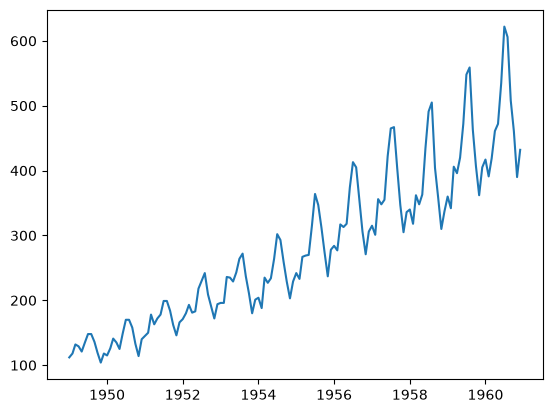

In [83]:
# Visualização da série temporal completa
plt.plot(ts)

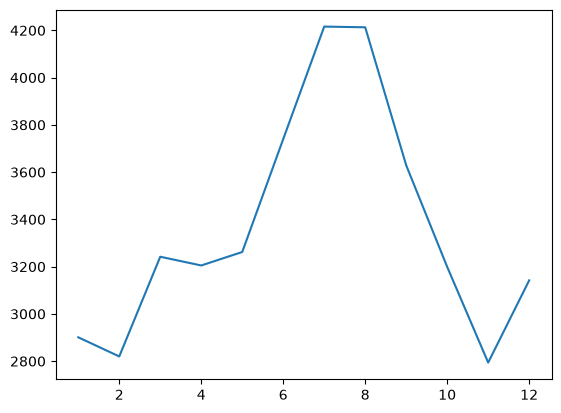

In [85]:
# Visualização por mês (reune todos os janeiros num valor só, todos os fevereiros num valor... para comparar os meses de maior fluxo independente do ano)
ts_mes = ts.groupby([lambda x: x.month]).sum()
plt.plot(ts_mes)

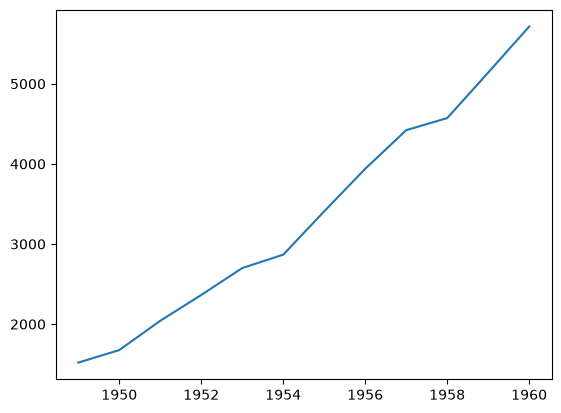

In [86]:
# Visualização por ano
ts_ano = ts.groupby([lambda x: x.year]).sum()
plt.plot(ts_ano)

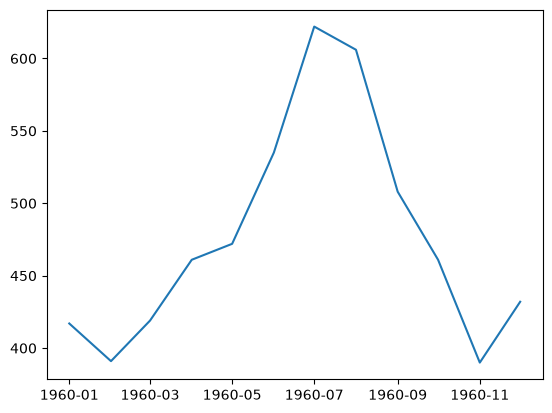

In [87]:
# Visualização entre datas específicas
ts_datas = base.loc['1960-01-01':'1960-12-01']
plt.plot(ts_datas)

# DECOMPOSIÇÃO DA SÉRIE

In [88]:
from statsmodels.tsa.seasonal import seasonal_decompose
# Decomposição da série temporal, criando uma variável para cada formato
decomposicao = seasonal_decompose(ts, model="additive") # modelo default é additive
decomposicao

In [89]:
#tendencia
tendencia = decomposicao.trend
tendencia

Month
1949-01-01   NaN
1949-02-01   NaN
1949-03-01   NaN
1949-04-01   NaN
1949-05-01   NaN
              ..
1960-08-01   NaN
1960-09-01   NaN
1960-10-01   NaN
1960-11-01   NaN
1960-12-01   NaN
Name: trend, Length: 144, dtype: float64

In [97]:
# no inicio e no fim os dados tão todos NAN, mas no meio não
print("Tamanho: ", len(tendencia), "Numero de NAN: ", np.isnan(tendencia).sum())

tendencia.describe()

Tamanho:  144 Numero de NAN:  12


count    132.000000
mean     278.001263
std      102.591115
min      126.791667
25%      190.729167
50%      259.479167
75%      372.229167
max      475.041667
Name: trend, dtype: float64

In [98]:
tendencia.head(10)

Month
1949-01-01           NaN
1949-02-01           NaN
1949-03-01           NaN
1949-04-01           NaN
1949-05-01           NaN
1949-06-01           NaN
1949-07-01    126.791667
1949-08-01    127.250000
1949-09-01    127.958333
1949-10-01    128.583333
Name: trend, dtype: float64

In [90]:
#sazonalidade
sazonal = decomposicao.seasonal
sazonal

Month
1949-01-01   -24.748737
1949-02-01   -36.188131
1949-03-01    -2.241162
1949-04-01    -8.036616
1949-05-01    -4.506313
                ...    
1960-08-01    62.823232
1960-09-01    16.520202
1960-10-01   -20.642677
1960-11-01   -53.593434
1960-12-01   -28.619949
Name: seasonal, Length: 144, dtype: float64

In [91]:
# ruido, erro ou residuo
ruido = decomposicao.resid
ruido

Month
1949-01-01   NaN
1949-02-01   NaN
1949-03-01   NaN
1949-04-01   NaN
1949-05-01   NaN
              ..
1960-08-01   NaN
1960-09-01   NaN
1960-10-01   NaN
1960-11-01   NaN
1960-12-01   NaN
Name: resid, Length: 144, dtype: float64

In [99]:
# mesmo caso da tendencia, tem muitos valores NAN nas pontas, mas no meio tem valores reais
print("Tamanho: ", len(ruido), "Numero de NAN: ", np.isnan(ruido).sum())

print(ruido.describe())

ruido.head(10)

Tamanho:  144 Numero de NAN:  12
count    132.000000
mean     278.001263
std      102.591115
min      126.791667
25%      190.729167
50%      259.479167
75%      372.229167
max      475.041667
Name: trend, dtype: float64


Month
1949-01-01          NaN
1949-02-01          NaN
1949-03-01          NaN
1949-04-01          NaN
1949-05-01          NaN
1949-06-01          NaN
1949-07-01   -42.622475
1949-08-01   -42.073232
1949-09-01    -8.478535
1949-10-01    11.059343
Name: resid, dtype: float64

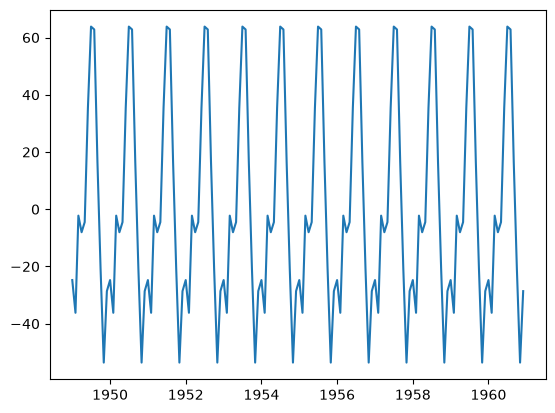

In [92]:
# Visualização de gráfico para cada formato da série temporal
plt.plot(sazonal)

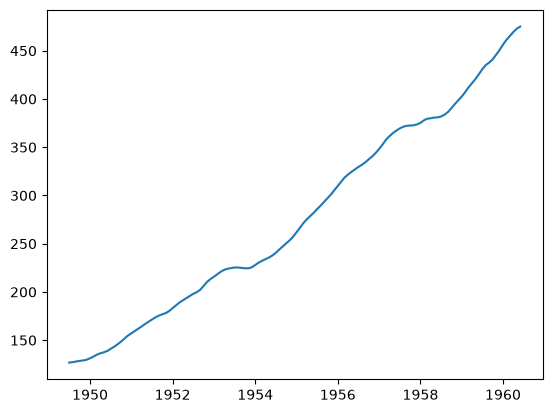

In [93]:
plt.plot(tendencia)

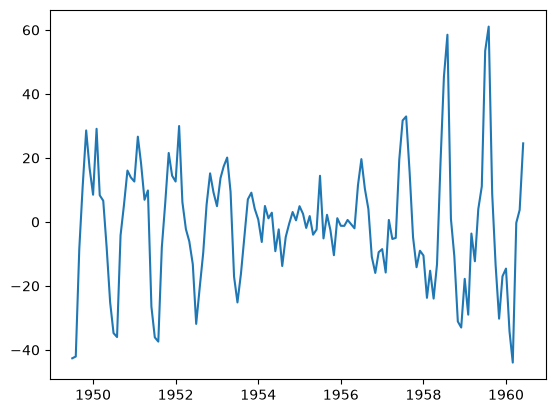

In [94]:
plt.plot(ruido)

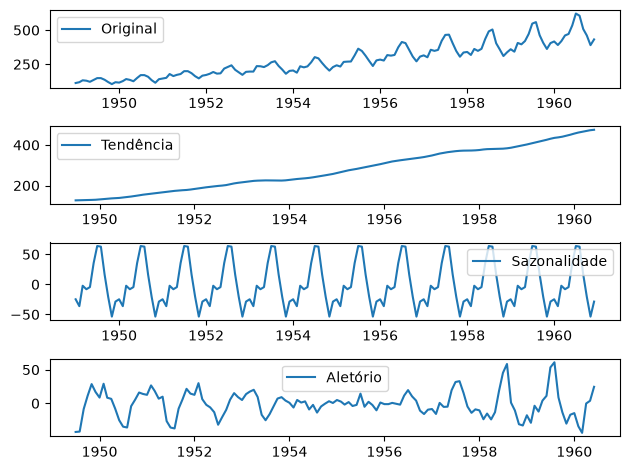

In [95]:
plt.subplot(4,1,1)
plt.plot(ts, label = 'Original')
plt.legend(loc = 'best')

# Visualização somente da tendência
plt.subplot(4,1,2)
plt.plot(tendencia, label = 'Tendência')
plt.legend(loc = 'best')

# Visualização somente da sazonalidade
plt.subplot(4,1,3)
plt.plot(sazonal, label = 'Sazonalidade')
plt.legend(loc = 'best')

# Visualização somente do elemento aleatório
plt.subplot(4,1,4)
plt.plot(ruido, label = 'Ruído')
plt.legend(loc = 'best')
plt.tight_layout()